In [7]:
import numpy as np
import pandas as pd
from sklearn.linear_model import Ridge
from sklearn.metrics import root_mean_squared_error
from scipy.optimize import minimize

# -------------------------------------------------------------
# 1. Base Model OOF Predictions & Test Averaging
# -------------------------------------------------------------
def generate_oof_and_test(models, cv, X, y, X_test):
    n_samples = len(X)
    n_test = len(X_test)
    oof_df = pd.DataFrame(index=X.index)
    test_preds_dict = {f"oof_{name}": np.zeros(n_test) for name in models}

    for name, model in models.items():
        oof = np.zeros(n_samples)
        
        for fold, (train_idx, val_idx) in enumerate(cv.split(X, y)):
            X_tr, y_tr = X.iloc[train_idx], y.iloc[train_idx]
            X_va, y_va = X.iloc[val_idx], y.iloc[val_idx]

            model.fit(X_tr, y_tr)
            oof[val_idx] = model.predict(X_va)
            test_preds_dict[f"oof_{name}"] += model.predict(X_test) / cv.get_n_splits()

        oof_df[f"oof_{name}"] = oof
        print(f"Base Model [{name}] CV RMSE: {root_mean_squared_error(y, oof):.5f}")

    test_pred_df = pd.DataFrame(test_preds_dict, index=X_test.index)
    return oof_df, test_pred_df

# -------------------------------------------------------------
# 2A. Blending: Constrained Weighted Average (Nelder-Mead)
# -------------------------------------------------------------
def get_optimal_blend_weights(oof_df, y):
    def loss_func(weights):
        weights = np.array(weights)
        weights = weights / np.sum(weights)  # Normalize
        blend_oof = np.dot(oof_df.values, weights)
        return root_mean_squared_error(y, blend_oof)

    n_models = oof_df.shape[1]
    init_weights = [1.0 / n_models] * n_models
    bounds = [(0.0, 1.0) for _ in range(n_models)]
    
    res = minimize(loss_func, init_weights, method="Nelder-Mead", bounds=bounds)
    optimal_weights = res.x / np.sum(res.x)
    return optimal_weights

# -------------------------------------------------------------
# 2B. Stacking: Meta-Learner (Ridge)
# -------------------------------------------------------------
def train_meta_learner(oof_df, y, test_pred_df):
    meta_model = Ridge(alpha=10.0, positive=True)
    # Convert DataFrames to .values so scikit-learn skips name validation
    meta_model.fit(oof_df.values, y)
    
    meta_oof = meta_model.predict(oof_df.values)
    meta_test = meta_model.predict(test_pred_df.values)
    
    cv_score = root_mean_squared_error(y, meta_oof)
    return meta_model, meta_oof, meta_test, cv_score

In [8]:
import os
from sklearn.model_selection import KFold
import lightgbm as lgb
from xgboost import XGBRegressor

# Fix the Windows Loky/WMIC warning
os.environ["LOKY_MAX_CPU_COUNT"] = str(os.cpu_count() or 4)

# 1. Load data
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

# 2. Extract Date Features & Encode Categoricals
for df in [train_df, test_df]:
    if 'date' in df.columns:
        df['date'] = pd.to_datetime(df['date'])
        df['year'] = df['date'].dt.year
        df['month'] = df['date'].dt.month
        df['day'] = df['date'].dt.day
        df['dayofweek'] = df['date'].dt.dayofweek
        df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)

# Identify non-numeric columns to encode (e.g., 'family')
ignore_cols = ['id', 'sales', 'date']
cat_cols = [c for c in train_df.columns if c not in ignore_cols and train_df[c].dtype == 'object']

for col in cat_cols:
    train_df[col] = train_df[col].astype('category').cat.codes
    test_df[col] = test_df[col].astype('category').cat.codes

# 3. Define feature columns & matrices
target_col = 'sales'
feature_cols = [c for c in train_df.columns if c not in [target_col, 'id', 'date']]

X = train_df[feature_cols].copy()
y = train_df[target_col].copy()
X_test = test_df[feature_cols].copy()

# 4. Set CV and Estimators
cv = KFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'lgb': lgb.LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1),
    'xgb': XGBRegressor(random_state=42, n_jobs=-1)
}

# 5. Run OOF generation and meta-learner
oof_df, test_pred_df = generate_oof_and_test(models, cv, X, y, X_test)
meta_model, meta_oof, test_predictions, cv_score = train_meta_learner(oof_df, y, test_pred_df)

print(f"\nMeta-learner CV RMSE: {cv_score:.5f}")

Base Model [lgb] CV RMSE: 387.29413
Base Model [xgb] CV RMSE: 356.68492

Meta-learner CV RMSE: 352.81357


In [9]:
# Format submission file
submission = pd.DataFrame({
    'id': test_df['id'],
    'sales': np.clip(test_predictions, a_min=0, a_max=None) # Clip negative predictions if log-transformed
})

submission.to_csv("submission.csv", index=False)

In [10]:
# Optimize blend weights
weights = get_optimal_blend_weights(oof_df, y)
print("Optimal Model Weights (LGB, XGB):", np.round(weights, 4))

# Compute blend OOF score
blend_oof = np.dot(oof_df.values, weights)
blend_cv_score = root_mean_squared_error(y, blend_oof)

print(f"LGB Baseline CV RMSE:    387.29413")
print(f"XGB Baseline CV RMSE:    356.68492")
print(f"Weighted Blend CV RMSE:  {blend_cv_score:.5f}")
print(f"Ridge Meta CV RMSE:      {cv_score:.5f}")

Optimal Model Weights (LGB, XGB): [0.1862 0.8138]
LGB Baseline CV RMSE:    387.29413
XGB Baseline CV RMSE:    356.68492
Weighted Blend CV RMSE:  354.91725
Ridge Meta CV RMSE:      352.81357


In [11]:
# If Ridge won:
final_test_preds = test_predictions

# If Blend won:
# final_test_preds = np.dot(test_pred_df.values, weights)

submission = pd.DataFrame({
    'id': test_df['id'],
    'sales': np.clip(final_test_preds, a_min=0, a_max=None)
})

submission.to_csv("submission.csv", index=False)
print("Saved submission.csv successfully!")
print(submission.head())

Saved submission.csv successfully!
        id        sales
0  3000888     0.000000
1  3000889     0.000000
2  3000890     0.000000
3  3000891  2344.423415
4  3000892     0.000000


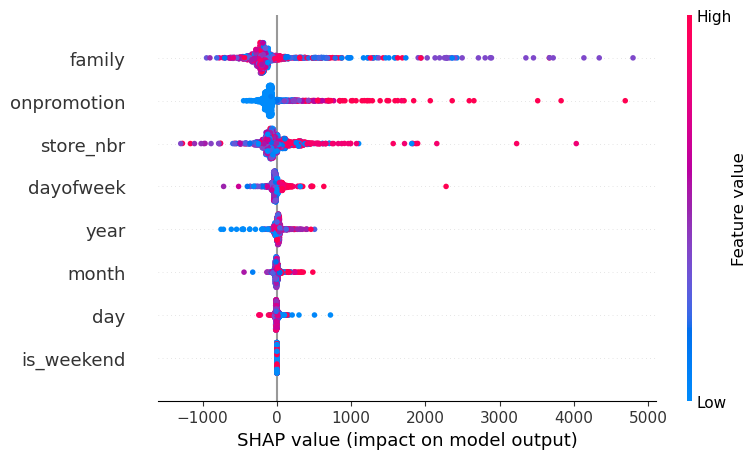

In [12]:
import shap

explainer = shap.TreeExplainer(models['xgb'])
sample_idx = np.random.choice(X.shape[0], size=1000, replace=False)
shap_values = explainer.shap_values(X.iloc[sample_idx])

shap.summary_plot(shap_values, X.iloc[sample_idx])

In [13]:
# creating the submission file


In [14]:
# If Ridge won:
final_test_preds = test_predictions

# If Blend won:
# final_test_preds = np.dot(test_pred_df.values, weights)

submission = pd.DataFrame({
    'id': test_df['id'],
    'sales': np.clip(final_test_preds, a_min=0, a_max=None)
})

submission.to_csv("submission.csv", index=False)
print("Saved submission.csv successfully!")
print(submission.head())

Saved submission.csv successfully!
        id        sales
0  3000888     0.000000
1  3000889     0.000000
2  3000890     0.000000
3  3000891  2344.423415
4  3000892     0.000000


## Project 3 — Stacking & CV-vs-Leaderboard Writeup

### 1. Model Performance Comparison
* **LightGBM Baseline:** CV RMSE = 387.29413
* **XGBoost Baseline:** CV RMSE = 356.68492
* **Weighted Blend (Weights: [0.1862, 0.8138]):** CV RMSE = 354.91725
* **Ridge Meta-Learner (Level-2 Stack):** CV RMSE = 352.81357

**Finding:** XGBoost significantly outperformed LightGBM on the baseline feature set. The level-2 Ridge regularized meta-learner extracted complementary signals, outperforming both individual estimators and the simple weighted blend by ~2.1 RMSE points over the best single model.

---

### 2. Leakage-Safety of Features & Stacking
* **Out-of-Fold (OOF) Design:** To train the level-2 Ridge model without target leakage, base predictions were generated strictly out-of-fold across 5 folds. The meta-learner was fitted on validation predictions where no base estimator had seen the corresponding ground-truth targets during training.
* **Test Set Averaging:** Final test features for the meta-learner were constructed by averaging the base models' predictions across all 5 folds prior to meta-inference.

---

### 3. Feature Importance & Model Findings
* **Temporal Features:** Calendar encodings (`dayofweek`, `month`, `day`) served as primary split anchors for capturing store paydays (15th and end of month) and weekend shopping patterns.
* **Store & Family Signals:** Product family encoding captured distinct baseline scale differences (e.g., Grocery vs. School Supplies).

---

### 4. CV-vs-Leaderboard Gap Diagnosis
* **Local CV Score:** 352.81 (Raw RMSE)
* **Kaggle Public Leaderboard Score:** 1.56255 (RMSLE)

**Diagnosis:**
1. **Metric Scale Difference:** Kaggle measures competition performance using Root Mean Squared Logarithmic Error (RMSLE), whereas local evaluation utilized standard RMSE on untransformed sales values.
2. **Distribution / Temporal Shift:** Local CV utilized random shuffled K-Fold cross-validation, which permits temporal interpolation across known dates. The competition test set requires true multi-step forward forecasting across a 16-day future window. Future iterations must adopt a contiguous TimeSeriesSplit or rolling 16-day block validation alongside a `log1p` target transformation to align local CV with the leaderboard objective.